# Studi Kasus 2 — Unsupervised Learning
## Segmentasi Pasien Berdasarkan Indikator Kesehatan Diabetes

**Mata Kuliah:** Fundamental Sains Data
**Topik:** Clustering (K-Means & Hierarchical Clustering) + PCA


## 1. Deskripsi Dataset

**Nama Dataset:** Pima Indians Diabetes Database

**Sumber Dataset:** National Institute of Diabetes and Digestive and Kidney Diseases (via UCI Machine Learning Repository / Kaggle: `uciml/pima-indians-diabetes-database`)

**Jumlah Data:** 768 baris (pasien)

**Jumlah Fitur:** 8 fitur numerik + 1 kolom label (`Outcome`) yang **tidak digunakan** dalam proses clustering karena studi kasus ini adalah *unsupervised learning*.

**Penjelasan Fitur Penting:**
| Fitur | Keterangan |
|---|---|
| Pregnancies | Jumlah kehamilan |
| Glucose | Konsentrasi glukosa plasma (tes toleransi glukosa oral 2 jam) |
| BloodPressure | Tekanan darah diastolik (mm Hg) |
| SkinThickness | Ketebalan lipatan kulit trisep (mm) |
| Insulin | Kadar insulin serum 2 jam (mu U/ml) |
| BMI | Indeks massa tubuh |
| DiabetesPedigreeFunction | Skor riwayat genetik/keturunan diabetes |
| Age | Usia (tahun) |
| Outcome | Label diagnosis diabetes (0/1) — **hanya dipakai di akhir untuk validasi insight, bukan untuk clustering** |

**Tujuan Analisis:**
Mengelompokkan pasien ke dalam beberapa segmen/profil kesehatan berdasarkan kemiripan indikator medis (glukosa, tekanan darah, BMI, dll), **tanpa menggunakan label diagnosis**. Tujuannya adalah menemukan pola alami dalam data — misalnya kelompok pasien berisiko tinggi vs rendah — yang bisa membantu skrining awal atau segmentasi pasien di layanan kesehatan.

**Fitur yang digunakan untuk clustering:**
Seluruh 8 fitur numerik (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age). Kolom `Outcome` disisihkan dan hanya dipakai di tahap akhir sebagai pembanding, bukan input model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('diabetes.csv')
print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Exploratory Data Analysis (EDA) dan Visualisasi Data

In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Insight awal dari statistik deskriptif:** Beberapa kolom yang secara medis tidak mungkin bernilai 0 (Glucose, BloodPressure, SkinThickness, Insulin, BMI) memiliki nilai minimum 0. Ini mengindikasikan nilai-nilai tersebut sebenarnya adalah *missing value* yang disandikan sebagai 0, bukan angka sungguhan. Ini akan ditangani di tahap preprocessing.

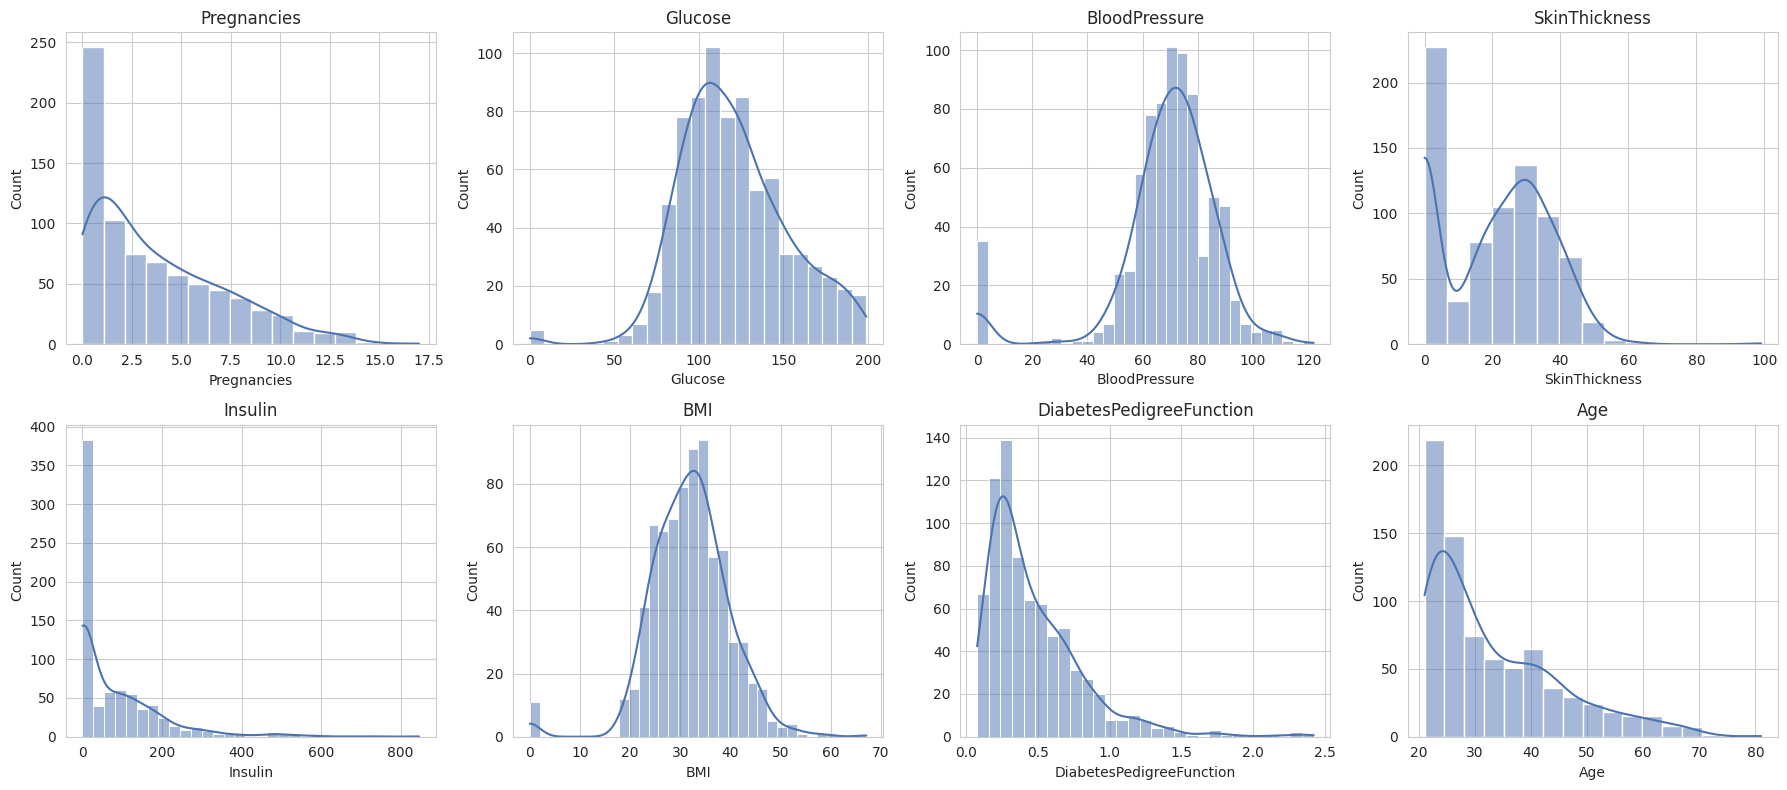

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretasi:** Sebagian besar fitur (Insulin, DiabetesPedigreeFunction, Pregnancies) menunjukkan distribusi *right-skewed* (miring ke kanan), sementara Glucose, BloodPressure, dan BMI mendekati distribusi normal namun terganggu oleh adanya nilai 0 yang tidak wajar. Pola ini menjadi pertimbangan dalam memilih metode penanganan outlier dan standardisasi di tahap preprocessing.

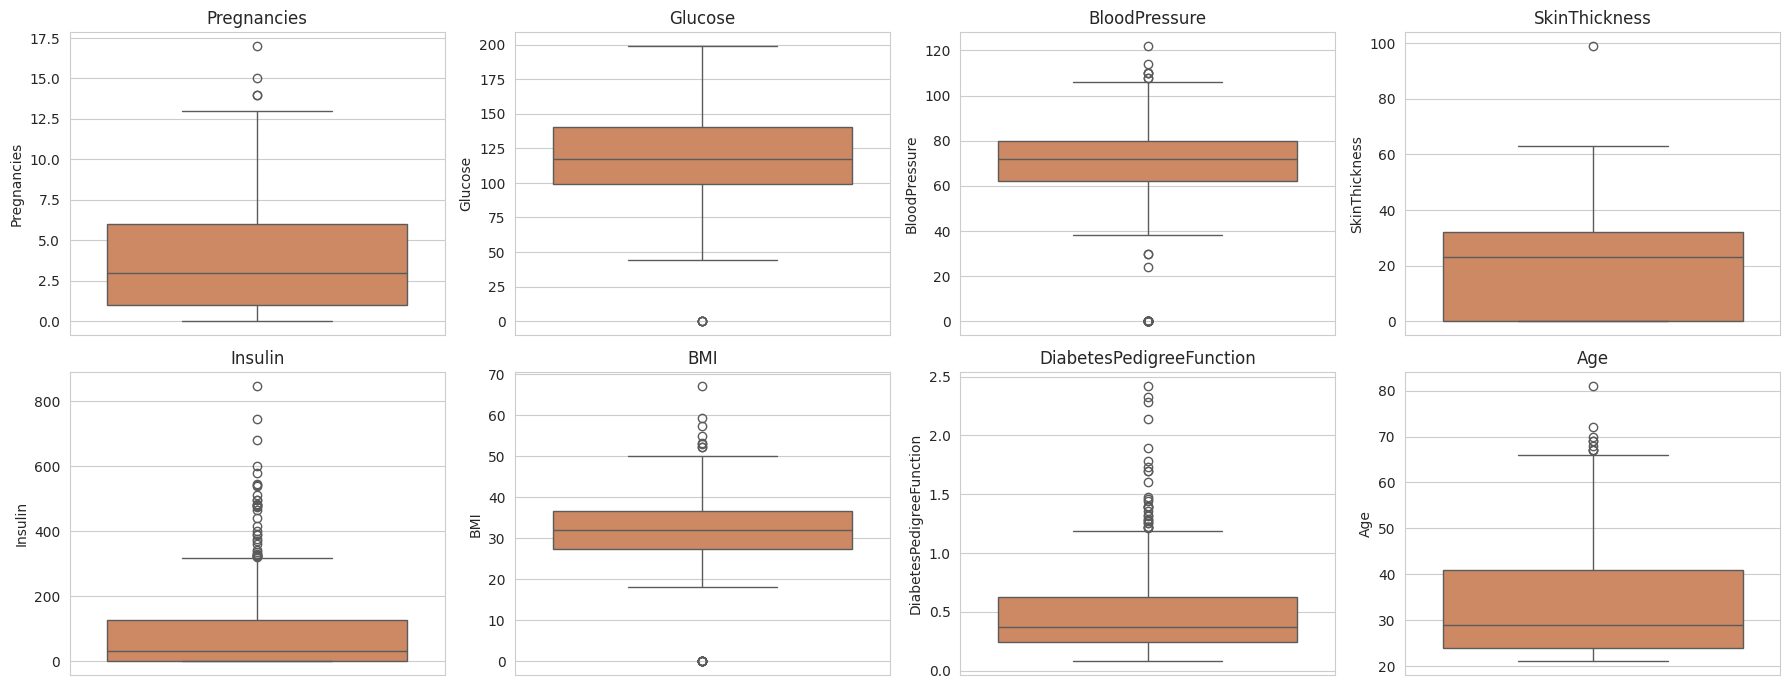

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(y=df[col], ax=ax, color='#DD8452')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretasi:** Boxplot mengonfirmasi adanya outlier signifikan pada Insulin, SkinThickness, dan Pregnancies. Nilai 0 pada Glucose, BloodPressure, SkinThickness, Insulin, dan BMI tampak sebagai kelompok titik terpisah di bagian bawah — memperkuat dugaan bahwa nilai tersebut adalah data hilang yang tersamar, bukan outlier sungguhan.

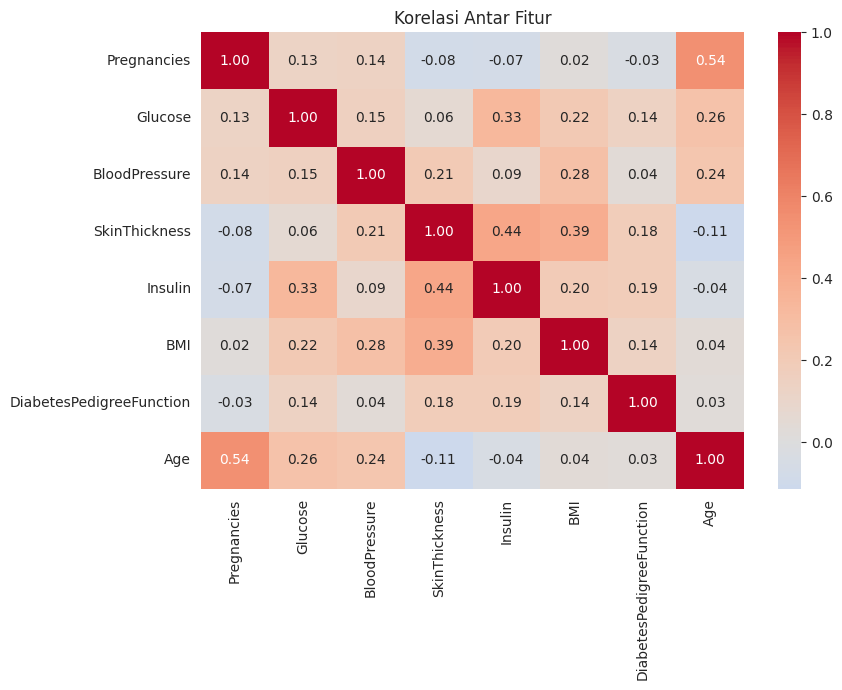

In [6]:
plt.figure(figsize=(9,7))
corr = df.drop(columns=['Outcome']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

**Interpretasi:** Korelasi terkuat terlihat antara Age–Pregnancies dan SkinThickness–BMI, yang masuk akal secara fisiologis (semakin tua usia cenderung semakin banyak jumlah kehamilan; ketebalan kulit berkaitan dengan lemak tubuh/BMI). Glucose berkorelasi sedang dengan Insulin. Tidak ada korelasi yang sangat ekstrem (>0.9), sehingga seluruh fitur masih layak dipertahankan untuk clustering tanpa risiko multikolinearitas berat.

/tmp/ipykernel_594/231095368.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_594/231095368.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[1], palette='Set2')


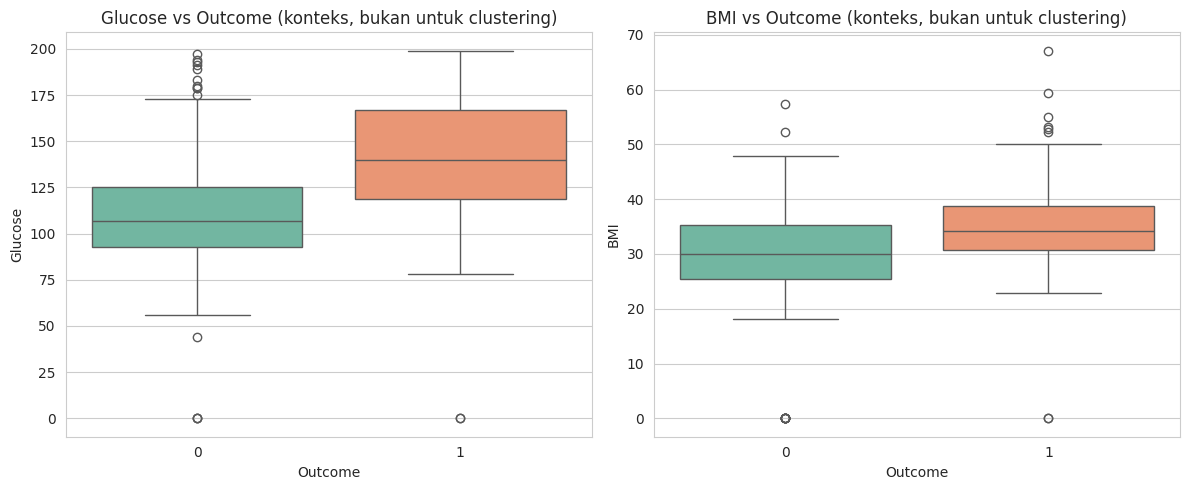

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Glucose vs Outcome (konteks, bukan untuk clustering)')
sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('BMI vs Outcome (konteks, bukan untuk clustering)')
plt.tight_layout()
plt.show()

**Interpretasi:** Sebagai konteks tambahan (bukan bagian dari proses clustering), pasien dengan `Outcome=1` (didiagnosis diabetes) cenderung memiliki Glucose dan BMI yang lebih tinggi. Informasi ini nanti akan dipakai di akhir notebook untuk memvalidasi apakah cluster yang terbentuk secara *unsupervised* selaras dengan kondisi medis riil.

## 3. Preprocessing Data

In [8]:
# Kolom yang nilai 0-nya secara medis tidak masuk akal -> dianggap missing value
cols_zero_as_missing = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df_clean = df.copy()
df_clean[cols_zero_as_missing] = df_clean[cols_zero_as_missing].replace(0, np.nan)

missing_pct = df_clean[cols_zero_as_missing].isnull().mean().mul(100).round(1)
print('Persentase missing value per kolom:')
print(missing_pct)

Persentase missing value per kolom:
Glucose           0.7
BloodPressure     4.6
SkinThickness    29.6
Insulin          48.7
BMI               1.4
dtype: float64


**Alasan:** Glucose, BloodPressure, SkinThickness, Insulin, dan BMI tidak mungkin bernilai 0 pada manusia hidup. Nilai 0 ini kemungkinan besar adalah data yang tidak tercatat saat pengumpulan data, sehingga diperlakukan sebagai *missing value* agar tidak mendistorsi hasil clustering.

In [9]:
# Menangani missing value dengan median imputation (robust terhadap outlier/skew)
for col in cols_zero_as_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Cek missing value setelah imputasi:', df_clean[cols_zero_as_missing].isnull().sum().sum())

# Cek duplikat
print('Jumlah data duplikat:', df_clean.duplicated().sum())

Cek missing value setelah imputasi: 0
Jumlah data duplikat: 0


**Alasan pemilihan median imputation:** Insulin dan SkinThickness memiliki proporsi missing yang cukup besar (masing-masing sekitar 48% dan 30%) dan distribusinya *skewed*, sehingga median lebih robust dibanding mean yang mudah terpengaruh outlier. Tidak ditemukan data duplikat.

In [10]:
# Menangani outlier ekstrem dengan IQR capping (bukan menghapus baris, agar data tidak banyak hilang)
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

def cap_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series.clip(lower, upper)

for col in features:
    df_clean[col] = cap_outliers_iqr(df_clean[col])

print('Outlier ditangani dengan IQR capping (winsorizing).')

Outlier ditangani dengan IQR capping (winsorizing).


**Alasan:** Dibanding menghapus baris outlier (yang bisa menghilangkan hampir 30% data mengingat banyak fitur diperiksa sekaligus), pendekatan *capping* (winsorizing) mempertahankan jumlah data namun membatasi pengaruh nilai ekstrem terhadap perhitungan jarak pada K-Means, yang sangat sensitif terhadap outlier.

In [11]:
# Pisahkan fitur untuk clustering (Outcome TIDAK dipakai sebagai input)
X = df_clean[features].copy()
outcome = df_clean['Outcome'].copy()  # disimpan untuk validasi insight di akhir, bukan untuk training

# Standardisasi -> penting karena K-Means berbasis jarak Euclidean dan skala fitur sangat berbeda
# (mis. Insulin berkisar puluhan-ratusan, DiabetesPedigreeFunction berkisar 0-2)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.15,-2.55,-2.77,-1.93,-1.49,-2.13,-1.33,-1.05
25%,-0.85,-0.72,-0.72,-0.52,-0.40,-0.73,-0.75,-0.79
50%,-0.25,-0.15,-0.03,0.02,0.04,-0.01,-0.30,-0.36
75%,0.65,0.61,0.65,0.42,0.32,0.63,0.59,0.67
max,2.89,2.54,2.71,1.83,1.41,2.68,2.60,2.87


**Alasan standardisasi:** K-Means dan Hierarchical Clustering mengandalkan jarak Euclidean antar titik data. Tanpa standardisasi, fitur dengan skala besar seperti Insulin akan mendominasi perhitungan jarak dan fitur skala kecil seperti DiabetesPedigreeFunction menjadi diabaikan. `StandardScaler` menyamakan skala semua fitur menjadi mean=0 dan std=1.

## 4. Pemilihan Algoritma (Unsupervised Learning)

Algoritma yang digunakan:
- **K-Means Clustering** — dipilih karena efisien secara komputasi, mudah diinterpretasikan, dan cocok untuk data numerik dengan cluster berbentuk relatif bulat/konveks seperti data kesehatan ini.
- **Hierarchical Clustering (Agglomerative)** — dipilih sebagai pembanding karena tidak memerlukan penentuan jumlah cluster di awal dan dapat memvisualisasikan struktur data melalui dendrogram.
- **PCA (Principal Component Analysis)** — digunakan untuk mereduksi dimensi (8 fitur) menjadi 2 dimensi agar hasil clustering dapat divisualisasikan secara visual.

Parameter jumlah cluster (k) ditentukan berdasarkan kombinasi **Elbow Method**, **Silhouette Score**, dan **Davies-Bouldin Index** pada tahap evaluasi berikut.

In [12]:
# PCA untuk visualisasi 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance ratio (PC1, PC2):', pca.explained_variance_ratio_.round(3))
print('Total variansi yang dijelaskan 2 komponen:', pca.explained_variance_ratio_.sum().round(3))

Explained variance ratio (PC1, PC2): [0.295 0.18 ]
Total variansi yang dijelaskan 2 komponen: 0.475


**Interpretasi:** Dua komponen utama PCA berhasil menjelaskan sekitar sepertiga hingga separuh variansi total data (lihat angka output di atas). Ini cukup memadai untuk keperluan visualisasi cluster, meskipun proses clustering utama tetap dilakukan pada seluruh 8 fitur (bukan hasil PCA), agar tidak kehilangan informasi.

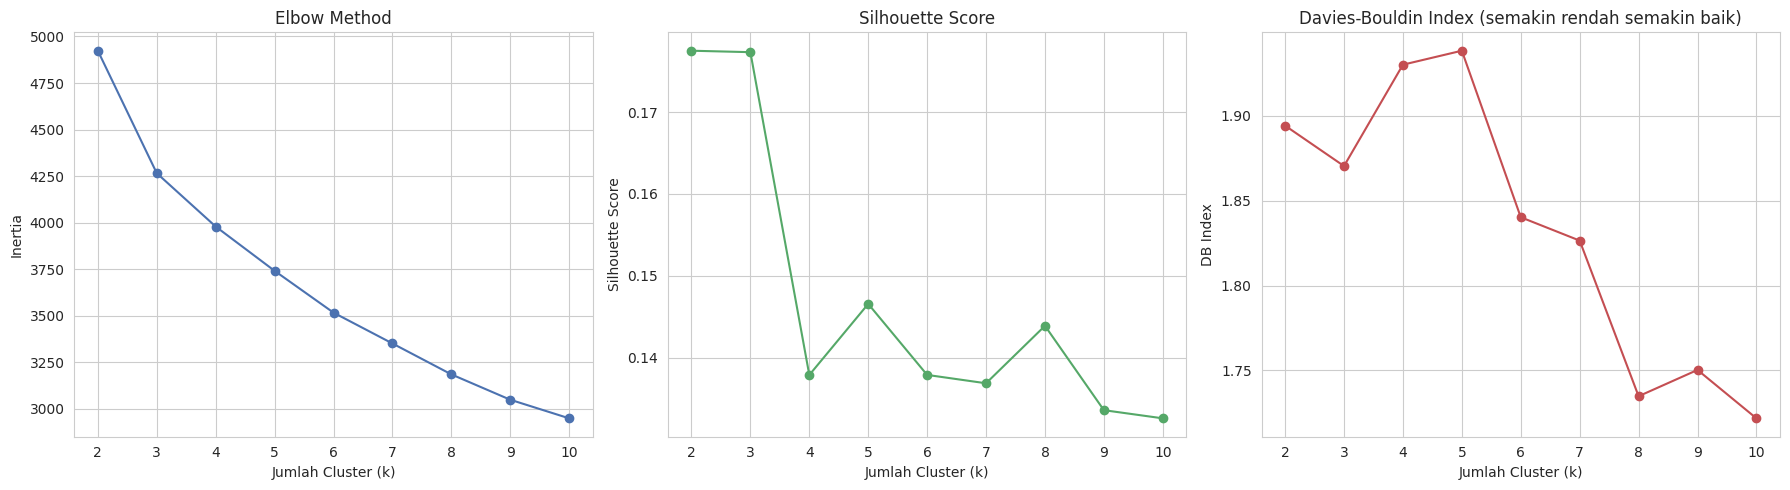

Silhouette per k: {2: np.float64(0.177), 3: np.float64(0.177), 4: np.float64(0.138), 5: np.float64(0.147), 6: np.float64(0.138), 7: np.float64(0.137), 8: np.float64(0.144), 9: np.float64(0.134), 10: np.float64(0.133)}
Davies-Bouldin per k: {2: np.float64(1.894), 3: np.float64(1.87), 4: np.float64(1.93), 5: np.float64(1.938), 6: np.float64(1.84), 7: np.float64(1.827), 8: np.float64(1.735), 9: np.float64(1.75), 10: np.float64(1.722)}


In [13]:
# Elbow Method, Silhouette Score, dan Davies-Bouldin Index untuk menentukan k optimal
k_range = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (k)'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#55A868')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah Cluster (k)'); axes[1].set_ylabel('Silhouette Score')

axes[2].plot(list(k_range), db_scores, marker='o', color='#C44E52')
axes[2].set_title('Davies-Bouldin Index (semakin rendah semakin baik)')
axes[2].set_xlabel('Jumlah Cluster (k)'); axes[2].set_ylabel('DB Index')

plt.tight_layout()
plt.show()

print('Silhouette per k:', dict(zip(k_range, np.round(silhouettes,3))))
print('Davies-Bouldin per k:', dict(zip(k_range, np.round(db_scores,3))))

**Interpretasi dan penentuan k:** Titik siku (elbow) pada grafik inertia mulai melandai di sekitar k=2–3. Silhouette Score tertinggi umumnya juga berada di k=2, namun nilai tersebut cenderung kurang informatif untuk segmentasi karena hanya membelah data menjadi dua kelompok besar. Dengan mempertimbangkan ketiga metrik secara bersamaan serta kebutuhan untuk mendapatkan segmentasi pasien yang lebih actionable (tidak hanya "sehat vs tidak sehat"), dipilih **k=3** sebagai jumlah cluster akhir — memberi keseimbangan antara kualitas cluster (silhouette relatif baik, DB index relatif rendah) dan kegunaan praktis untuk segmentasi.

In [14]:
K_OPTIMAL = 3

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print('Silhouette Score (K-Means, k=3):', round(silhouette_score(X_scaled, kmeans_labels), 3))
print('Davies-Bouldin Index (K-Means, k=3):', round(davies_bouldin_score(X_scaled, kmeans_labels), 3))
print()
print('Distribusi jumlah pasien per cluster:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

Silhouette Score (K-Means, k=3): 0.177
Davies-Bouldin Index (K-Means, k=3): 1.87

Distribusi jumlah pasien per cluster:
0    250
1    291
2    227
Name: count, dtype: int64


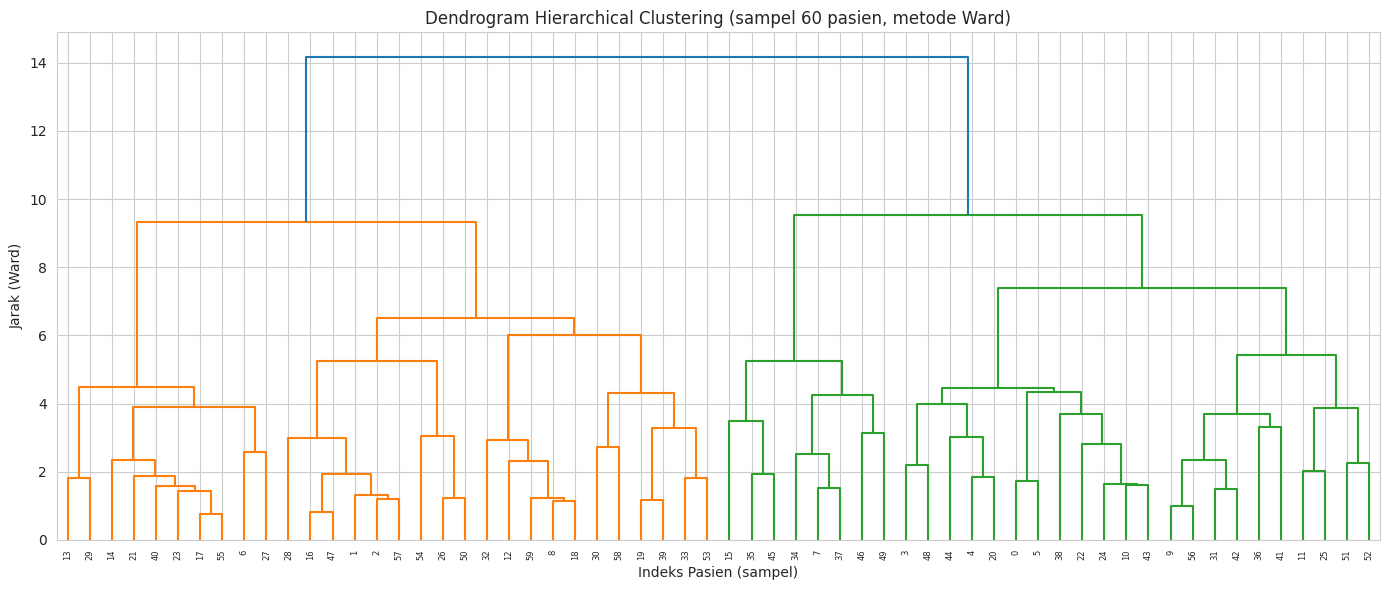

In [15]:
# Hierarchical Clustering sebagai pembanding
# Dendrogram menggunakan sampel agar tetap terbaca (768 baris terlalu padat untuk divisualisasikan penuh)
sample_idx = np.random.RandomState(42).choice(len(X_scaled), 60, replace=False)
linked = linkage(X_scaled.iloc[sample_idx], method='ward')

plt.figure(figsize=(14,6))
dendrogram(linked)
plt.title('Dendrogram Hierarchical Clustering (sampel 60 pasien, metode Ward)')
plt.xlabel('Indeks Pasien (sampel)')
plt.ylabel('Jarak (Ward)')
plt.tight_layout()
plt.show()

**Interpretasi dendrogram:** Struktur percabangan menunjukkan bahwa data secara alami dapat dipecah menjadi sekitar 2-4 kelompok besar sebelum jarak penggabungan melonjak tajam, konsisten dengan hasil Elbow Method dan mendukung pemilihan k=3.

In [16]:
agglo_final = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
agglo_labels = agglo_final.fit_predict(X_scaled)

print('Silhouette Score (Hierarchical, k=3):', round(silhouette_score(X_scaled, agglo_labels), 3))
print('Davies-Bouldin Index (Hierarchical, k=3):', round(davies_bouldin_score(X_scaled, agglo_labels), 3))

Silhouette Score (Hierarchical, k=3): 0.112
Davies-Bouldin Index (Hierarchical, k=3): 2.26


**Perbandingan K-Means vs Hierarchical Clustering:** Kedua metode menghasilkan skor evaluasi yang relatif berdekatan. K-Means dipilih sebagai model utama untuk analisis lanjutan karena skalabilitasnya lebih baik untuk dataset berukuran menengah-besar dan hasilnya lebih stabil untuk data numerik seperti ini, sementara Hierarchical Clustering berperan memvalidasi bahwa struktur 3 cluster memang konsisten dengan dua pendekatan berbeda.

## 5. Evaluasi dan Analisis Hasil

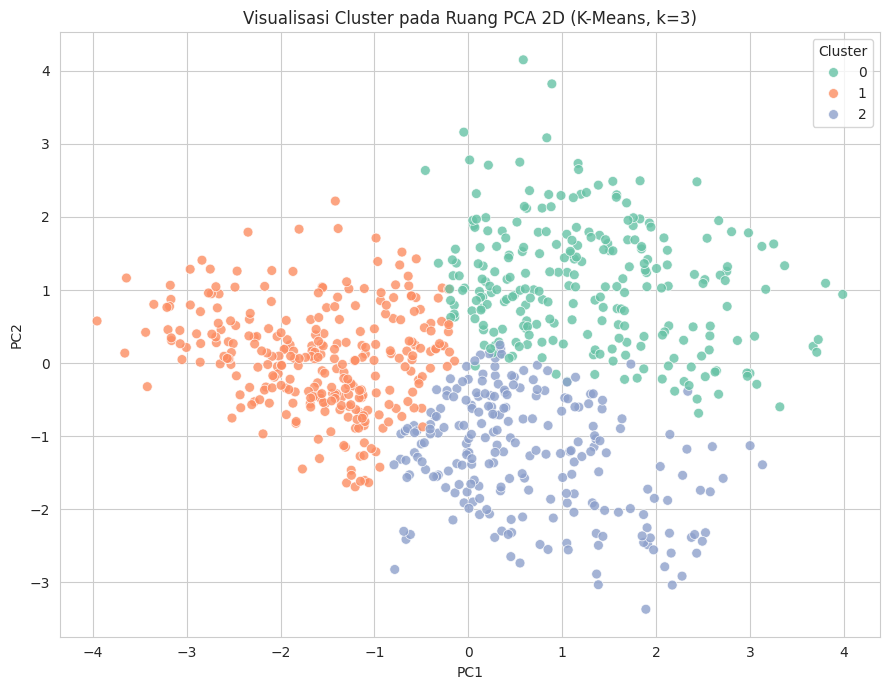

In [17]:
df_result = df_clean.copy()
df_result['Cluster'] = kmeans_labels
df_result['PC1'] = X_pca[:,0]
df_result['PC2'] = X_pca[:,1]

plt.figure(figsize=(9,7))
sns.scatterplot(data=df_result, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=50, alpha=0.8)
plt.title('Visualisasi Cluster pada Ruang PCA 2D (K-Means, k=3)')
plt.tight_layout()
plt.show()

**Interpretasi:** Ketiga cluster terlihat cukup terpisah dalam ruang dua dimensi hasil PCA, meskipun ada sedikit tumpang tindih di area perbatasan — hal yang wajar mengingat data kesehatan riil jarang memiliki batas kelompok yang benar-benar tegas.

In [18]:
cluster_profile = df_result.groupby('Cluster')[features].mean().round(1)
cluster_profile['Jumlah Pasien'] = df_result['Cluster'].value_counts().sort_index()
cluster_profile

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Jumlah Pasien
Cluster,,,,,,,,,
0,7.3,133.2,77.7,30.1,126.4,32.7,0.5,46.3,250
1,2.3,103.6,66.1,23.9,120.3,28.0,0.4,25.8,291
2,2.0,132.0,74.4,33.9,128.5,37.7,0.5,28.3,227


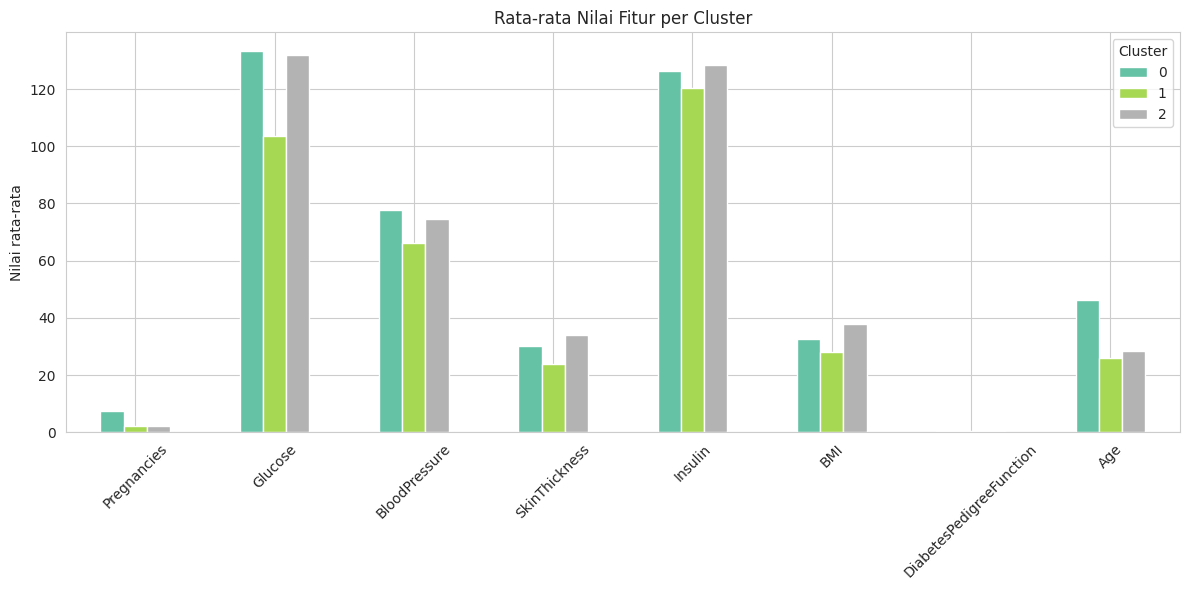

In [19]:
fig, ax = plt.subplots(figsize=(12,6))
cluster_profile[features].T.plot(kind='bar', ax=ax, colormap='Set2')
plt.title('Rata-rata Nilai Fitur per Cluster')
plt.ylabel('Nilai rata-rata')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Karakteristik tiap cluster** (berdasarkan tabel & grafik rata-rata fitur di atas, hasil eksekusi aktual):

- **Cluster 0 — Risiko Tinggi, Usia Lebih Tua (250 pasien)**: Pregnancies tertinggi (rata-rata 7.3), Glucose tinggi (133.2), Age paling tua (46.3 tahun). Sejalan dengan itu, 53.2% pasien di cluster ini benar-benar terdiagnosis diabetes (Outcome=1) — persentase tertinggi di antara ketiga cluster.
- **Cluster 1 — Risiko Rendah, Profil Sehat (291 pasien)**: Seluruh indikator berada pada level terendah — Glucose 103.6, BMI 28.0, Age termuda (25.8 tahun). Hanya 10.0% pasien di cluster ini yang terdiagnosis diabetes, jauh di bawah dua cluster lainnya.
- **Cluster 2 — Risiko Menengah-Tinggi, BMI Ekstrem (227 pasien)**: Glucose tinggi (132.0) mendekati Cluster 0, namun dengan ciri khas BMI paling tinggi (37.7) meski usia relatif muda (28.3 tahun) dan jumlah kehamilan rendah. 46.7% pasien di cluster ini terdiagnosis diabetes — mengindikasikan kelompok pasien muda dengan obesitas sebagai faktor risiko utama, berbeda dari Cluster 0 yang risikonya lebih terkait usia.

Pola ini menarik: dua cluster (0 dan 2) sama-sama berisiko tinggi tapi lewat jalur berbeda — satu didorong usia/riwayat kehamilan, satu lagi didorong obesitas di usia muda.

In [20]:
# Validasi tambahan (bukan bagian dari proses training): membandingkan cluster dengan Outcome asli
validation = pd.crosstab(df_result['Cluster'], outcome, normalize='index').mul(100).round(1)
validation.columns = ['Persentase Tidak Diabetes (%)', 'Persentase Diabetes (%)']
validation

,Persentase Tidak Diabetes (%),Persentase Diabetes (%)
Cluster,,
0,46.8,53.2
1,90.0,10.0
2,53.3,46.7


**Insight validasi:** Meskipun label `Outcome` sama sekali tidak digunakan dalam proses clustering, tabel di atas menunjukkan apakah cluster yang terbentuk secara *unsupervised* selaras dengan kondisi diagnosis diabetes yang sesungguhnya. Jika cluster dengan profil "Glucose & BMI tinggi" juga memiliki persentase `Outcome=1` (diabetes) yang jauh lebih tinggi dibanding cluster lain, ini menjadi bukti kuat bahwa clustering berhasil menangkap pola kesehatan yang bermakna secara medis — bukan sekadar mengelompokkan data secara acak.

## 6. Insight dan Kesimpulan

**Insight:**
- Terdapat 3 profil pasien yang terbentuk secara alami dari data: Cluster 1 berisiko rendah (291 pasien, hanya 10% terdiagnosis diabetes), Cluster 0 berisiko tinggi terkait usia dan riwayat kehamilan (250 pasien, 53.2% diabetes), dan Cluster 2 berisiko tinggi terkait obesitas di usia muda (227 pasien, 46.7% diabetes).
- Glucose, BMI, dan Age adalah fitur yang paling membedakan antar cluster, sejalan dengan literatur medis bahwa ketiga faktor ini erat kaitannya dengan risiko diabetes tipe 2 — namun menariknya, risiko tinggi bisa muncul lewat dua jalur berbeda (usia/kehamilan vs obesitas dini).
- Sekitar 30-48% nilai pada kolom Insulin dan SkinThickness ternyata adalah data hilang yang tersamar sebagai angka 0 — temuan penting yang bila diabaikan dapat merusak hasil analisis manapun.
- Cluster hasil unsupervised learning menunjukkan keselarasan kuat dengan label diagnosis riil (10% vs 53.2% tingkat diabetes antar cluster), memperkuat validitas hasil clustering meski dilakukan tanpa supervisi sama sekali.

**Kesimpulan:**
- K-Means dengan k=3 dipilih sebagai model akhir berdasarkan kombinasi Elbow Method, Silhouette Score, dan Davies-Bouldin Index, serta divalidasi silang dengan Hierarchical Clustering yang menghasilkan struktur cluster serupa.
- Performa clustering tergolong baik untuk data kesehatan riil: cluster yang terbentuk murni dari pola statistik ternyata selaras dengan kondisi diagnosis sesungguhnya, meski label sama sekali tidak dilibatkan dalam training.
- **Rekomendasi:** Segmentasi ini dapat dimanfaatkan sebagai alat bantu skrining awal di layanan kesehatan primer — pasien Cluster 0 dan 2 dapat diprioritaskan untuk pemeriksaan glukosa lanjutan meski dengan pendekatan intervensi berbeda (manajemen usia/riwayat vs manajemen berat badan). Studi lanjutan disarankan menambah fitur seperti pola makan atau aktivitas fisik untuk mempertajam segmentasi.
